In [13]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
data_dir = r'C:\Users\sp6497_a\OneDrive - Princeton University\20260430 uv-vis'
csv_path = os.path.join(data_dir, 'test_export.csv')

raw = pd.read_csv(csv_path, header=None)
sample_row = raw.iloc[0]
data = raw.iloc[2:].reset_index(drop=True).apply(pd.to_numeric, errors='coerce').dropna(subset=[0])

samples = {}
for col_idx in range(0, len(sample_row), 2):
    name = sample_row[col_idx]
    if pd.notna(name) and str(name).strip():
        wavelength = data.iloc[:, col_idx].values
        pct_T = data.iloc[:, col_idx + 1].values
        samples[name] = (wavelength, pct_T)

In [15]:
# raw
# sample_row
raw.iloc[1]

0    Wavelength (nm)
1                 %T
2    Wavelength (nm)
3                 %T
4    Wavelength (nm)
5                 %T
6    Wavelength (nm)
7                 %T
8                NaN
Name: 1, dtype: object

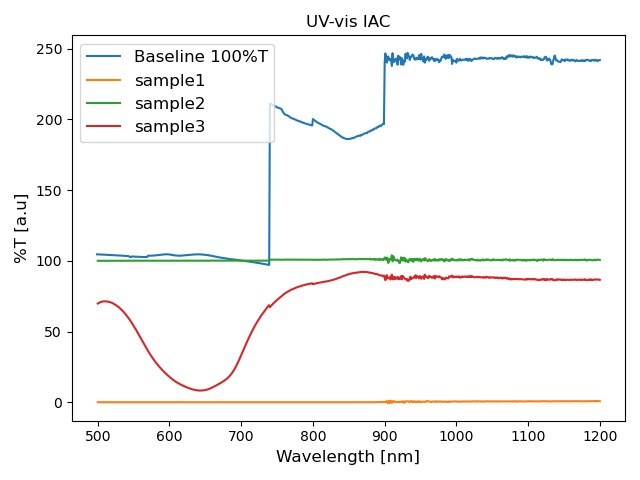

In [16]:
%matplotlib widget
fig, ax = plt.subplots()
ax.set_title('UV-vis IAC')
ax.set_xlabel('Wavelength [nm]', fontsize=12)
ax.set_ylabel('%T [a.u]', fontsize=12)

for name, (wl, pct_t) in samples.items():
    ax.plot(wl, pct_t, label=name)

ax.legend(prop={'size': 12})
plt.tight_layout()
plt.savefig(os.path.join(data_dir, 'raw_data.jpg'))